In [60]:
import sys
import os
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.resolve()))
from src.paths import *
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
from pathlib import Path


In [61]:
topic_names = {
    "T01": "OpenSSL installation/build and runtime errors",
    "T02": "Encoding and byte/string conversions (Base64, binary)",
    "T03": "X.509 certificates, signing, and trust chains",
    "T04": "Password hashing with salt (bcrypt, rainbow tables)",
    "T05": "Crypto library/API implementation in code",
    "T06": "Number theory for crypto (primes, factoring, modular arithmetic)",
    "T07": "Public-key cryptography: encryption and digital signatures",
    "T08": "Block cipher modes, IV/nonce, and padding",
    "T09": "Client-server secure communication (HTTP/HTTPS, sessions)",
    "T10": "User authentication and account management",
    "T11": "File handling, integrity checks & checksums",
    "T12": "Security vs performance (cost, speed, hardware limits)",
    "T13": "Password strength and entropy estimation",
    "T14": "Secure random number generation (entropy, seeding, PRNG)",
    "T15": "Cryptographic hash functions & collisions",
    "T16": "Key sizes and security parameters selection",
    "T17": "Key protection on devices (memory/disk access, threat model)",
    "T18": "Application data encryption & key storage",
    "T19": "Cryptosystem design pitfalls & attack resistance",
    "T20": "Trust, vendors, and real-world security risk",
    "T21": "Conceptual crypto explanations and learning",
}

In [62]:
def fused_difficulty(df: pd.DataFrame):
    """
    Compute difficulty metrics and return a DataFrame with columns:
      - topic
      - avg_hours: mean hours until accepted answer (per topic)
      - avg_no_accepted_answer: proportion of questions without accepted_answer_id (per topic)
      - T_hat: avg_hours / global_mean(avg_hours)
      - P_hat: avg_no_accepted_answer / global_mean(avg_no_accepted_answer)
      - fused_difficulty: (P_hat + T_hat) / 2
    """

    if 'creation_date' not in df.columns:
        raise ValueError("DataFrame must contain 'creation_date' column.")
    if 'type' not in df.columns:
        raise ValueError("DataFrame must contain 'type' column.")
    if 'topic' not in df.columns:
        raise ValueError("DataFrame must contain 'topic' column.")

    if 'accepted_answer_id' not in df.columns:
        df['accepted_answer_id'] = pd.NA

    df['creation_date'] = pd.to_datetime(df['creation_date'], errors='coerce')

    answers = df[df['type'] == 'answer'][['question_id', 'id', 'creation_date']].copy()
    answers['creation_date'] = pd.to_datetime(answers['creation_date'], errors='coerce')
    answers.rename(columns={'id': 'AnswerId', 'creation_date': 'answer_creation_date'}, inplace=True)

    questions = df[df['type'] == 'question'].copy()

    questions_with_accepted = questions[questions['accepted_answer_id'].notna()].copy()
    merged = pd.merge(
        questions_with_accepted,
        answers,
        left_on='accepted_answer_id',
        right_on='AnswerId',
        how='inner'
    )

    merged['hours_to_accepted_answer'] = (
        merged['answer_creation_date'] - merged['creation_date']
    ).dt.total_seconds() / 3600

    merged = merged[merged['hours_to_accepted_answer'].notna() & (merged['hours_to_accepted_answer'] >= 0)]

    topic_avg_hours = (
        merged.groupby('topic', as_index=True)['hours_to_accepted_answer']
        .mean()
        .rename('avg_hours')
        .to_frame()
    )

    total_q_by_topic = questions.groupby('topic').size().rename('total_q')
    no_acc_by_topic = questions[questions['accepted_answer_id'].isna()].groupby('topic').size().rename('no_acc_q')

    not_acc_df = pd.concat([total_q_by_topic, no_acc_by_topic], axis=1).fillna(0)
    not_acc_df['avg_no_accepted_answer'] = not_acc_df['no_acc_q'] / not_acc_df['total_q']
    not_acc_df = not_acc_df[['avg_no_accepted_answer']]

    all_topics = pd.Index(sorted(set(list(topic_avg_hours.index) + list(not_acc_df.index))))
    base_df = pd.DataFrame(index=all_topics)

    base_df = base_df.join(topic_avg_hours, how='left')
    base_df = base_df.join(not_acc_df, how='left')

    if base_df['avg_hours'].notna().any():
        global_mean_hours = base_df['avg_hours'].mean(skipna=True)
    else:
        global_mean_hours = 1.0

    base_df['avg_hours'] = base_df['avg_hours'].fillna(global_mean_hours)

    if global_mean_hours == 0:
        base_df['T_hat'] = 0.0
    else:
        base_df['T_hat'] = base_df['avg_hours'] / global_mean_hours

    base_df['avg_no_accepted_answer'] = base_df['avg_no_accepted_answer'].fillna(0.0)
    global_mean_no_acc = base_df['avg_no_accepted_answer'].mean()
    if global_mean_no_acc == 0:
        base_df['P_hat'] = 0.0
    else:
        base_df['P_hat'] = base_df['avg_no_accepted_answer'] / global_mean_no_acc

    base_df['fused_difficulty'] = (base_df['P_hat'] + base_df['T_hat']) / 2

    result = base_df.reset_index().rename(columns={'index': 'topic'})
    result = result[['topic', 'avg_hours', 'avg_no_accepted_answer', 'T_hat', 'P_hat', 'fused_difficulty']]

    return result


def calculate_popularity(df: pd.DataFrame, num_topics: int):
    """
    Compute popularity metrics per topic using normalized averages:
        V_hat = avg_views / global_mean(avg_views)
        S_hat = avg_score / global_mean(avg_score)
        C_hat = avg_comments / global_mean(avg_comments)
        fused_popularity = (V_hat + S_hat + C_hat) / 3
    Returns a DataFrame with topic and avg metrics.
    """

    questions_df = df[(df['type'] == 'question') & (df['topic'].notna())].copy()

    metric_cols = {
        'view_count': 'avg_views',
        'score': 'avg_score',
        'comment_count': 'avg_comments'
    }

    for col in metric_cols.keys():
        if col not in questions_df.columns:
            raise ValueError(f"Missing required metric column: {col}")

    topic_metrics = (
        questions_df
        .groupby('topic')[list(metric_cols.keys())]
        .mean()
        .rename(columns=metric_cols)
    )

    global_means = topic_metrics.mean()

    topic_metrics['V_hat'] = topic_metrics['avg_views'] / global_means['avg_views']
    topic_metrics['S_hat'] = topic_metrics['avg_score'] / global_means['avg_score']
    topic_metrics['C_hat'] = topic_metrics['avg_comments'] / global_means['avg_comments']

    topic_metrics['fused_popularity'] = topic_metrics[['V_hat', 'S_hat', 'C_hat']].mean(axis=1)

    result_df = topic_metrics.reset_index()

    return result_df


def generate_fused_scatter(fused_metadata_path=FUSED_METADATA, fused_plot_path=None):
    import matplotlib.patheffects as pe
    from matplotlib.colors import hsv_to_rgb

    fused_metadata_path = Path(fused_metadata_path)
    if fused_plot_path is None:
        fused_plot_path = fused_metadata_path.with_suffix('.png')
    fused_plot_path = Path(fused_plot_path)

    df = pd.read_csv(fused_metadata_path)
    
    x_mid = df['fused_popularity'].mean()
    y_mid = df['fused_difficulty'].mean()

    unique_topics = sorted(list(df['topic'].unique()))
    n_topics = len(unique_topics)

    distinct_colors = [
        "#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
        "#911eb4", "#46f0f0", "#f032e6", "#bcf60c", "#fabebe",
        "#008080", "#e6beff", "#9a6324", "#fffac8", "#800000",
        "#aaffc3", "#808000", "#ffd8b1", "#000075", "#808080",
        "#000000"
]

    if n_topics > len(distinct_colors):
        raise ValueError("Paleta insuficiente para o número de tópicos.")

    color_map = dict(zip(unique_topics, distinct_colors[:n_topics]))
    topic_name_to_id = {name: topic_id for topic_id, name in topic_names.items()}

    plt.figure(figsize=(14, 11)) 
    bubble_size = 1200 

    for topic in unique_topics:
        subset = df[df['topic'] == topic]
        topic_key = str(topic).strip()
        if topic_key in topic_names:
            abbrev = topic_key
        elif topic_key in topic_name_to_id:
            abbrev = topic_name_to_id[topic_key]
        elif topic_key.isdigit() and f"T{topic_key.zfill(2)}" in topic_names:
            abbrev = f"T{topic_key.zfill(2)}"
        elif topic_key.startswith('T'):
            abbrev = topic_key
        else:
            abbrev = f"T{topic_key.zfill(2)}" if topic_key.isdigit() else topic_key
        plt.scatter(
            subset['fused_popularity'],
            subset['fused_difficulty'],
            s=bubble_size,
            color=color_map[topic],
            alpha=0.8,
            edgecolor="black",
            linewidth=1.2,
        )

        point_x = subset['fused_popularity'].mean()
        point_y = subset['fused_difficulty'].mean()
        text = plt.text(
            point_x,
            point_y,
            abbrev,
            ha="center",
            va="center",
            color="white",
            fontsize=10,
            fontweight="bold"
        )
        text.set_path_effects([pe.withStroke(linewidth=2.2, foreground="black")])

    plt.axvline(x_mid, color="black", linestyle="--", linewidth=0.8, alpha=0.3)
    plt.axhline(y_mid, color="black", linestyle="--", linewidth=0.8, alpha=0.3)

    pad_x = (df['fused_popularity'].max() - df['fused_popularity'].min()) * 0.05
    pad_y = (df['fused_difficulty'].max() - df['fused_difficulty'].min()) * 0.05
    
    plt.text(x_mid - pad_x, y_mid + pad_y, "Unpopular & Difficult", ha="right", alpha=0.6, weight='bold')
    plt.text(x_mid + pad_x, y_mid + pad_y, "Popular & Difficult", ha="left", alpha=0.6, weight='bold')

    plt.text(x_mid - pad_x, y_mid - (pad_y * 1.8), "Unpopular & Easy", ha="right", alpha=0.6, weight='bold')
    plt.text(x_mid + pad_x, y_mid - (pad_y * 1.8), "Popular & Easy", ha="left", alpha=0.6, weight='bold')

    plt.xlabel("Popularity", fontsize=12)
    plt.ylabel("Difficulty", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(fused_plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    return fused_plot_path


def main(model_path):

    if not Path(model_path / LDA_CONFIG).exists():
        raise FileNotFoundError(f"LDA config file not found at {model_path / LDA_CONFIG}")

    with open(model_path / LDA_CONFIG, 'r', encoding='utf-8') as f:
        lda_config = json.load(f)

    num_topics = lda_config.get('num_topics')
    if num_topics is None:
        raise ValueError("'num_topics' (K) missing in LDA config")

    if not CLASSIFIED_POSTS.exists():
        raise FileNotFoundError(
            f"Classified posts file not found at {CLASSIFIED_POSTS}")

    df = pd.read_csv(CLASSIFIED_POSTS)

    popularity_df = calculate_popularity(df, num_topics)
    difficulty_df = fused_difficulty(df)

    fused_metrics_df = pd.merge(popularity_df, difficulty_df, on='topic', how='outer')
    fused_metrics_df.to_csv(FUSED_METADATA, index=False)

    print(f"Fused popularity and difficulty metrics saved to {FUSED_METADATA}")
    print(fused_metrics_df)

    plot_path = generate_fused_scatter(FUSED_METADATA, FUSED_PLOT)
    print(f"Fused scatter plot saved to {plot_path}")



from scipy.stats import kendalltau


def generate_kendall_corr_csv(input_path=FUSED_METADATA, output_path=KENDAL_CORR):
    df = pd.read_csv(input_path)
    
    pop_metrics = ['avg_views', 'avg_comments', 'avg_score'] 
    diff_metrics = ['avg_no_accepted_answer', 'avg_hours']     
    results = []

    for pop in pop_metrics:
        row = {'Pop/Diff metrics': f"{pop.replace('avg_', '').capitalize()} (avg)"}
        for diff in diff_metrics:
            tau, p_val = kendalltau(df[pop], df[diff])
            
            col_name = diff.replace('avg_', '').replace('_', ' ')
            row[col_name] = f"{tau:.3f} [{p_val:.3f}]"
        results.append(row)
    
    tau_f, p_f = kendalltau(df['fused_popularity'], df['fused_difficulty'])
    
    fused_row = {
        'Pop/Diff metrics': 'Fused Popularity vs Fused Difficulty',
        'no accepted answer': f"{tau_f:.3f} [{p_f:.3f}]",
        'hours': ''
    }
    results.append(fused_row)
    
    df_final = pd.DataFrame(results)
    df_final.to_csv(output_path, index=False, encoding='utf-8')
    print(df_final)
    print(f"Correlation table saved to: {output_path}")


/tmp/ipykernel_1716906/3141902914.py:243: DtypeWarning: Columns (1,3,16,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CLASSIFIED_POSTS)


Fused popularity and difficulty metrics saved to /home/reset-workstation/Documentos/social-media-dev-crawler/data/notebook_outputs/rq2/csvs/fused_metadata.csv
                                                topic     avg_views  \
0           Application data encryption & key storage  25068.844262   
1           Block cipher modes, IV/nonce, and padding  21268.470588   
2   Client-server secure communication (HTTP/HTTPS...  23881.092166   
3         Conceptual crypto explanations and learning   9690.277778   
4           Crypto library/API implementation in code  31493.894737   
5           Cryptographic hash functions & collisions  25604.441718   
6    Cryptosystem design pitfalls & attack resistance  19791.446970   
7   Encoding and byte/string conversions (Base64, ...  29073.131356   
8         File handling, integrity checks & checksums  25333.128079   
9   Key protection on devices (memory/disk access,...  15936.370629   
10        Key sizes and security parameters selection  35506

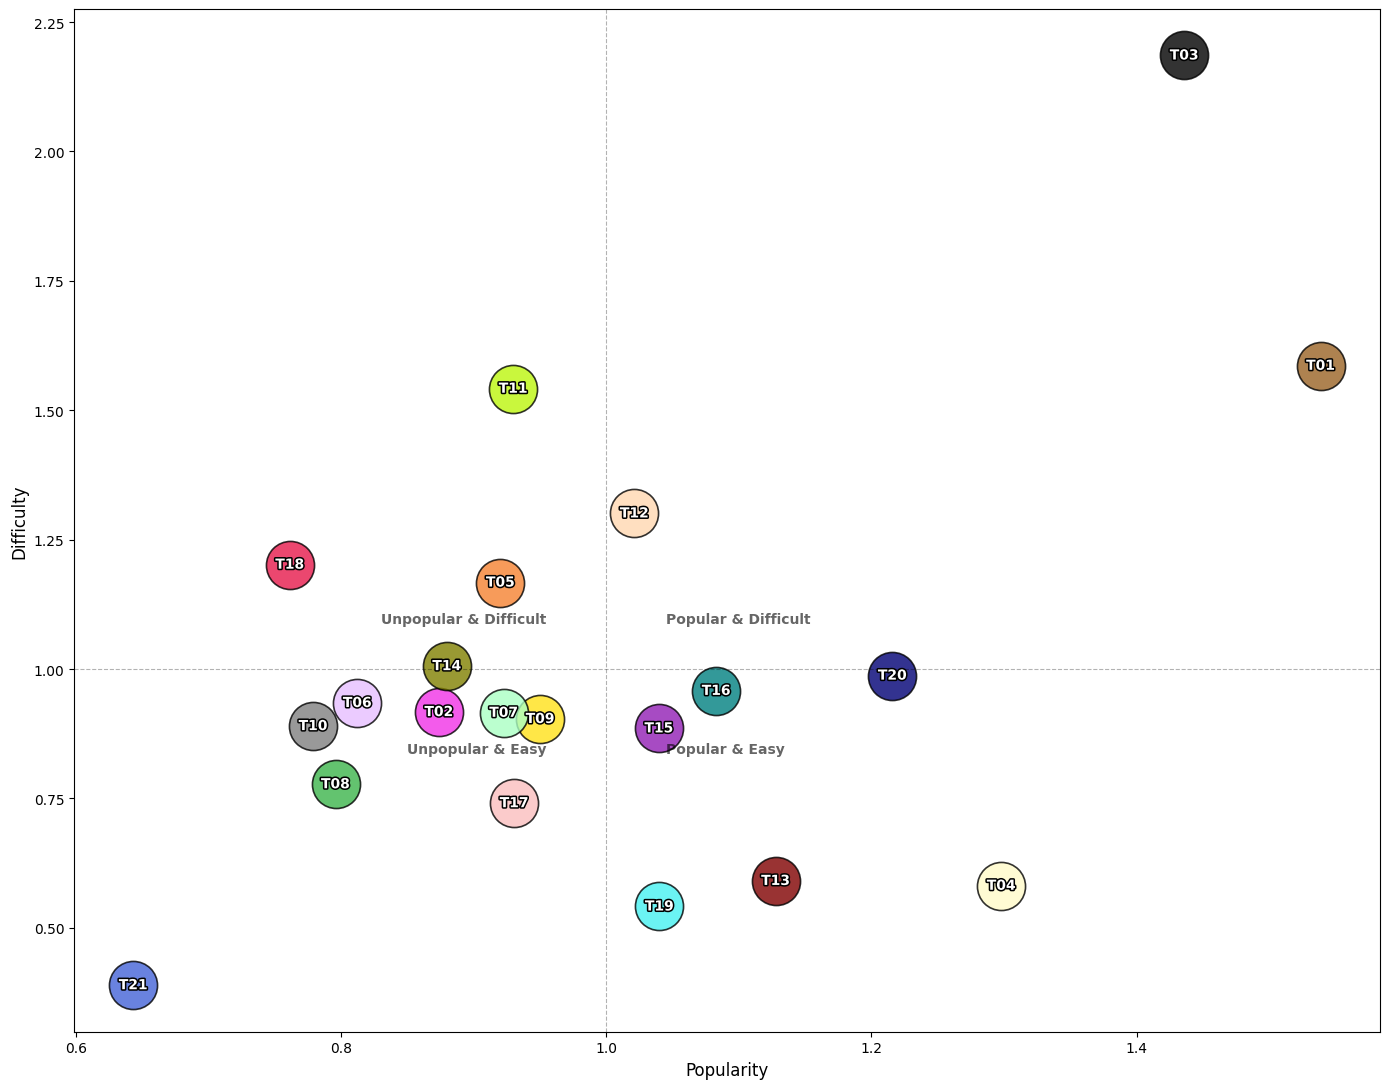

Fused scatter plot saved to /home/reset-workstation/Documentos/social-media-dev-crawler/data/notebook_outputs/rq2/plots/fused_plot.pdf


In [63]:
main(MODELS / 'main')

In [64]:
generate_kendall_corr_csv()

                       Pop/Diff metrics no accepted answer           hours
0                           Views (avg)     -0.029 [0.882]   0.448 [0.004]
1                        Comments (avg)     -0.095 [0.571]  -0.381 [0.016]
2                           Score (avg)      0.114 [0.492]   0.038 [0.835]
3  Fused Popularity vs Fused Difficulty      0.105 [0.531]                
Correlation table saved to: /home/reset-workstation/Documentos/social-media-dev-crawler/data/notebook_outputs/rq2/csvs/kendall_correlation_table.csv
